In [10]:
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt

def gather_results(results_folder,
                   epochs = None, classes = None, percents = None, runs = None,
                   base = True, retrain = True):

    # gather subdirectories
    all_subdirs = []
    for root, dirs, files in os.walk(results_folder):
        for d in dirs:
            all_subdirs.append(os.path.join(root, d))
            
    # if epochs is not None:
    #     epoch_dirs = [d for d in all_subdirs if "epoch" in d]
    #     pattern = rf"_({'|'.join(map(str, epochs))})$"
    #     dirs_to_remove = [d for d in epoch_dirs if not re.search(pattern, d)]
    #     all_subdirs = [d for d in all_subdirs if d not in dirs_to_remove]

    # if not base:
    #     all_subdirs = [d for d in all_subdirs if "base" not in d]

    # if not retrain:
    #     all_subdirs = [d for d in all_subdirs if "retrain" not in d]

    # gather results
    all_results = []
    for subdir in all_subdirs:

        # grab json files in this subdir
        file_paths = glob.glob(os.path.join(subdir, "*.json"))
        
        # remove the config json if it exists
        file_paths = [f for f in file_paths if "config" not in f]
        
        # # remove any unnecessary classes, percents, runs
        # if classes is not None:
        #     pattern = rf"class_({'|'.join(map(str, classes))})"
        #     file_paths = [f for f in file_paths if re.search(pattern, f)]

        # if percents is not None:
        #     pattern = rf"percent_({'|'.join(map(str, percents))})"
        #     file_paths = [f for f in file_paths if re.search(pattern, f)]

        # if runs is not None:
        #     pattern = rf"run_({'|'.join(map(str, runs))})"
        #     file_paths = [f for f in file_paths if re.search(pattern, f)]
        
        # Check if anything is left AFTER filtering
        if not file_paths:
            continue
        
        # add jsons for these file paths
        all_jsons = []
        for f in file_paths:
            data = pd.read_json(f, typ='series')
            
            # # add class if none
            # match = re.search(r'class_(\d+)', f)
            # if match:
            #     data['class'] = int(match.group(1))
            # else:
            #     data['class'] = -99  # default value if no match

            # # add percent if none
            # match = re.search(r'percent_(\d+)', f)
            # if match:
            #     data['percent'] = int(match.group(1))
            # else:
            #     data['percent'] = -99  # default value if no match

            # add epoch if none
            # match = re.search(r'base', f)
            # if match:
            #     data['epoch'] = -99

            # match = re.search(r'retrain', f)
            # if match:
            #     data['epoch'] = -98

            # # add run if none
            # match = re.search(r'run_(\d+)', f)
            # if match:
            #     data['run'] = int(match.group(1))
            # else:
            #     data['run'] = -99  # default value if no match

            all_jsons.append(data)

        # and concat and append to main df
        df = pd.concat(all_jsons, axis=1).T
        all_results.append(df)
    if not all_results:
        raise ValueError("No results - check settings")
    final_df = pd.concat(all_results, axis=0)


    # if "MIA" in final_df.columns:

    #     expanded_MIA = pd.json_normalize(final_df['MIA'])

    #     # json_normalize resets the index, so you MUST align it with your original dataframe
    #     expanded_MIA.index = final_df.index

    #     # Optional prefixing
    #     expanded_MIA = expanded_MIA.add_prefix('MIA_')

    #     # 2. Drop the original nested column and concatenate
    #     final_df = pd.concat([final_df.drop('MIA', axis=1), expanded_MIA], axis=1)

    return final_df


def results_barchart(final_df):
    """
    Creates a grouped bar chart showing the mean and standard deviation 
    of train_acc and test_acc for each epoch.
    """
    
    # 1. Prepare data (Tidy/Melt format)
    # We convert 'train_acc' and 'test_acc' into a single 'Metric' column
    df_melted = final_df.melt(
        id_vars=['num_epochs'], 
        value_vars=['train_acc', 'test_acc'], 
        var_name='Metric', 
        value_name='Accuracy'
    )
    
    # Clean up the metric names for the legend
    df_melted['Metric'] = df_melted['Metric'].str.replace('_', ' ').str.capitalize()

    # 2. Plotting
    plt.clf()
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")
    
    # Create the bar chart
    # errorbar='sd' calculates the standard deviation
    g = sns.barplot(
        data=df_melted, 
        x='num_epochs', 
        y='Accuracy', 
        hue='Metric',
        errorbar='sd', 
        capsize=.1,
        palette=['#1f77b4', '#ff7f0e'] 
    )

    # 3. Calculate statistics
    stats = df_melted.groupby(['num_epochs', 'Metric'])['Accuracy'].agg(['mean', 'std']).reset_index()


    # 4. Add labels above bars
    for container in g.containers:
        # We need to map the bars to their stats
        # Bar order matches the order of groups in the plot
        labels = []
        for i, bar in enumerate(container):
            height = bar.get_height()
            if height > 0:
                # Find the corresponding row in stats
                # Note: This assumes standard seaborn plotting order
                stat_row = stats.iloc[i] 
                label = f"{height:.2f}\n({stat_row['std']:.2f})"
                labels.append(label)
            else:
                labels.append("")
            
        g.bar_label(container, labels=labels, padding=5, fontsize=11)
    
    # 3. Formatting
    plt.title("Training and Test Accuracy, by Number of Training Epochs")
    plt.xlabel("Number of Training Epochs")
    plt.ylabel("Accuracy")
    
    # Customizing X-axis labels to replace special epoch identifiers
    # We extract existing labels and map them to friendly names
    # labels = [item.get_text() for item in g.get_xticklabels()]
    # new_labels = ["base" if l == "-99" or l == "-99.0" else "retrain" if l == "-98" or l == "-98.0" else l for l in labels]
    # g.set_xticklabels(new_labels)
    
    # Move legend outside to avoid obscuring bars
    plt.legend(title="Metric Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    
    plt.ylim(0, 115)
    # plt.tight_layout()
    plt.show()

<Figure size 640x480 with 0 Axes>

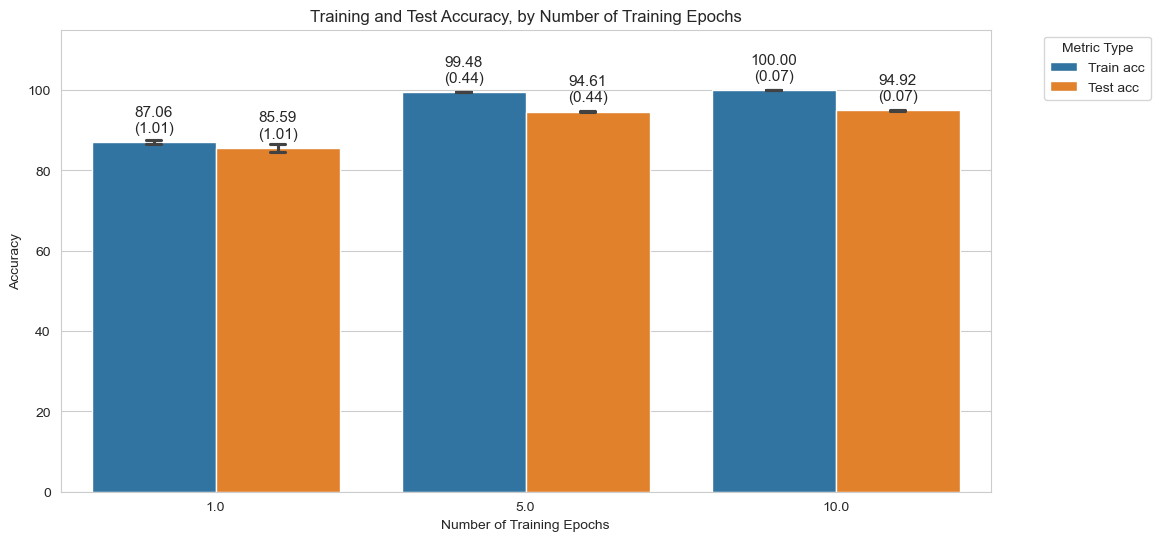

In [11]:
results = gather_results("results/pretraining/seed_3")
results["test_acc"] = results["test_acc"]
results_barchart(results)